# KFall — Acc + Gyr, 6 features

CNN + SE, GAP + Global Max Pooling. Augmentation và balanced class weight; window 200, step 50. Threshold được chọn trên Validation; không fine-tuning.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

import tensorflow as tf
from tensorflow.keras import Model, Input, layers
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)
print("TensorFlow Version:", tf.__version__)


In [ ]:
from pathlib import Path


feature_cols = [
    "AccX", "AccY", "AccZ",
    "GyrX", "GyrY", "GyrZ",
]
N_FEATURES = len(feature_cols)
WINDOW_SIZE = 200
WINDOW_STEP = 50
FALL_RATIO_THRESHOLD = 0.20
BASELINE_DECISION_THRESHOLD = 0.5
DECISION_THRESHOLD = BASELINE_DECISION_THRESHOLD
MODEL_DIR = Path("saved_models_6ft")
EXPECTED_TEST_SUBJECTS = ["SA21", "SA23", "SA24", "SA26", "SA30", "SA33"]
EXPECTED_TEST_COUNTS_BY_STEP = {
    50: (3714, 3392, 322),
    100: (1999, 1845, 154),
}


def resolve_dataset_path(*relative_candidates):
    """Resolve dataset paths whether the notebook runs from workspace or project root."""
    candidates = [Path.cwd() / candidate for candidate in relative_candidates]
    candidates.extend(Path.cwd().parent / candidate for candidate in relative_candidates)
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    searched = ", ".join(str(candidate) for candidate in candidates)
    raise FileNotFoundError(f"Không tìm thấy dataset. Đã tìm: {searched}")


def load_imu_dataset(data_path):
    """Read raw ACC/GYR rows and recording identifiers."""
    data_path = Path(data_path)
    csv_files = sorted(data_path.rglob("*.csv"))
    print(f"Đang đọc {len(csv_files)} file CSV từ: {data_path}")

    required_cols = {"FrameCounter", "FallCheck", *feature_cols}
    dfs = []
    for file_path in csv_files:
        df = pd.read_csv(file_path, usecols=lambda col: col in required_cols)
        missing_cols = required_cols.difference(df.columns)
        if missing_cols:
            raise ValueError(f"{file_path} thiếu cột: {sorted(missing_cols)}")

        if not np.isfinite(df[feature_cols].to_numpy()).all():
            raise ValueError(f"NaN/Inf trong features: {file_path}")
        if df["FrameCounter"].duplicated().any():
            raise ValueError(f"FrameCounter bị lặp: {file_path}")
        if not df["FallCheck"].isin([0, 1]).all():
            raise ValueError(f"FallCheck không phải 0/1: {file_path}")
        relative_path = file_path.relative_to(data_path)
        df["source_file"] = file_path.name
        df["recording_id"] = relative_path.with_suffix("").as_posix()
        df["subject_id"] = file_path.parent.name
        dfs.append(df)

    if not dfs:
        raise ValueError(f"Không tìm thấy file CSV nào tại: {data_path}")
    return pd.concat(dfs, ignore_index=True)


def create_sliding_windows(df, feature_cols, target_col, window_size, step):
    """Create fixed-length windows and label them by the Fall ratio threshold."""
    if window_size <= 0 or step <= 0:
        raise ValueError("window_size và step phải > 0")
    windows = []
    labels = []
    recording_ids = []
    subject_ids = []

    for recording_id, recording in df.groupby("recording_id", sort=False):
        recording = recording.sort_values("FrameCounter")
        if recording["subject_id"].nunique() != 1 or recording["FrameCounter"].duplicated().any():
            raise ValueError(f"Recording/frames bị trùng: {recording_id}")
        values = recording[feature_cols].to_numpy(dtype=np.float32)
        recording_labels = recording[target_col].to_numpy(dtype=np.int8)
        subject_id = recording["subject_id"].iloc[0]

        if len(recording) < window_size:
            continue

        for start in range(0, len(recording) - window_size + 1, step):
            end = start + window_size
            windows.append(values[start:end].reshape(-1))
            window_labels = recording_labels[start:end]
            fall_ratio = np.mean(window_labels == 1)
            labels.append(int(fall_ratio >= FALL_RATIO_THRESHOLD))
            recording_ids.append(recording_id)
            subject_ids.append(subject_id)

    if not windows:
        raise ValueError("Không tạo được sliding window nào. Kiểm tra window_size.")

    return (
        np.asarray(windows, dtype=np.float32),
        np.asarray(labels, dtype=np.int8),
        np.asarray(recording_ids),
        np.asarray(subject_ids),
    )


In [ ]:
# Đường dẫn dữ liệu huấn luyện: đọc toàn bộ các subject trong Sample_Training
train_path = resolve_dataset_path(
    "Fall_Detection_SIC_Capstone/fall_detection_dataset/Sample_Training",
    "fall_detection_dataset/Sample_Training",
)

df_train_all = load_imu_dataset(train_path)

print(f"\nKích thước tập Training: {df_train_all.shape}")
print(f"Số subject: {df_train_all['subject_id'].nunique()}")
print(f"Số recording: {df_train_all['recording_id'].nunique()}")
print("\nSố recording theo subject:")
print(df_train_all.groupby("subject_id")["recording_id"].nunique().describe())

print("\nPhân bố nhãn FallCheck (0: Bình thường, 1: Ngã):")
val_counts = df_train_all["FallCheck"].value_counts().sort_index()
print(val_counts)
print(f"Tỷ lệ mẫu ngã: {val_counts.get(1, 0) / len(df_train_all) * 100:.2f}%")


### 3. Phân chia Train / Validation theo Subject & Chuẩn hóa



In [ ]:
target_col = "FallCheck"


P_JITTER = 0.30
P_SCALING = 0.30
P_ROTATION = 0.30

ACC_AXIS_NAMES = ["AccX", "AccY", "AccZ"]
ACC_AXIS_INDICES = [feature_cols.index(name) for name in ACC_AXIS_NAMES]
GYR_AXIS_NAMES = ["GyrX", "GyrY", "GyrZ"]
GYR_AXIS_INDICES = [feature_cols.index(name) for name in GYR_AXIS_NAMES]


def to_window_tensor(X):
    """Convert flattened windows to (samples, time, features)."""
    X = np.asarray(X, dtype=np.float32)
    if X.ndim == 2 and X.shape[1] == WINDOW_SIZE * len(feature_cols):
        return X.reshape(-1, WINDOW_SIZE, len(feature_cols))
    return X


def from_window_tensor(X):
    """Convert window tensors back to flattened model inputs."""
    X = np.asarray(X, dtype=np.float32)
    if X.ndim == 3 and X.shape[1] == WINDOW_SIZE and X.shape[2] == len(feature_cols):
        return X.reshape(X.shape[0], -1)
    return X


def augment_jitter_window(window, sigma=0.05):
    """Add independent Gaussian noise to raw Acc XYZ only."""
    augmented = window.copy()
    if len(ACC_AXIS_INDICES) == 3:
        noise = np.random.normal(0.0, sigma, size=(WINDOW_SIZE, 3)).astype(np.float32)
        augmented[:, ACC_AXIS_INDICES] += noise
    return augmented


def augment_scaling_window(window, sigma=0.10):
    """Scale all Acc XYZ together."""
    augmented = window.copy()
    if len(ACC_AXIS_INDICES) == 3:
        acc_scale = np.float32(np.random.normal(1.0, sigma))
        augmented[:, ACC_AXIS_INDICES] *= acc_scale
    return augmented


def augment_rotation_window(window):
    """Rotate ACC and GYR into the same coordinate frame."""
    augmented = window.copy()
    angle_range = np.pi / 18
    ax, ay, az = np.random.uniform(-angle_range, angle_range, size=3)

    Rx = np.array([[1.0, 0.0, 0.0], [0.0, np.cos(ax), -np.sin(ax)], [0.0, np.sin(ax), np.cos(ax)]], dtype=np.float32)
    Ry = np.array([[np.cos(ay), 0.0, np.sin(ay)], [0.0, 1.0, 0.0], [-np.sin(ay), 0.0, np.cos(ay)]], dtype=np.float32)
    Rz = np.array([[np.cos(az), -np.sin(az), 0.0], [np.sin(az), np.cos(az), 0.0], [0.0, 0.0, 1.0]], dtype=np.float32)
    rotation = Rz @ Ry @ Rx

    if len(ACC_AXIS_INDICES) == 3:
        augmented[:, ACC_AXIS_INDICES] = augmented[:, ACC_AXIS_INDICES] @ rotation.T
        augmented[:, GYR_AXIS_INDICES] = augmented[:, GYR_AXIS_INDICES] @ rotation.T
    return augmented


def apply_augmentations(X, y):
    """Augment each raw training window independently; validation/test are never passed here."""
    raw_windows = to_window_tensor(X)
    augmented_windows = raw_windows.copy()
    y_aug = np.asarray(y, dtype=np.int32).copy()

    for sample_index in range(raw_windows.shape[0]):
        window = raw_windows[sample_index].copy()
        if np.random.rand() < P_JITTER:
            window = augment_jitter_window(window)
        if np.random.rand() < P_SCALING:
            window = augment_scaling_window(window)
        if np.random.rand() < P_ROTATION:
            window = augment_rotation_window(window)
        augmented_windows[sample_index] = window

    return from_window_tensor(augmented_windows), y_aug


def scale_windows(X, fitted_scaler):
    """Scale windows using one feature-wise scaler fitted on raw Train rows."""
    tensor = to_window_tensor(X)
    shape = tensor.shape
    rows = pd.DataFrame(tensor.reshape(-1, N_FEATURES), columns=feature_cols)
    scaled = fitted_scaler.transform(rows)
    return scaled.reshape(shape).reshape(shape[0], -1).astype(np.float32)


groups = df_train_all["subject_id"].to_numpy()
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(df_train_all[feature_cols], df_train_all[target_col], groups=groups))

# Split raw data first. No scaler or augmentation is applied to validation data.
train_df = df_train_all.iloc[train_idx].copy()
val_df = df_train_all.iloc[val_idx].copy()

assert set(train_df["subject_id"].unique()).isdisjoint(set(val_df["subject_id"].unique())), (
    "Leakage: subject overlap detected between train and validation"
)

# Sliding Window -> raw train/validation windows.
X_train_raw, y_train, train_recordings, train_window_subjects = create_sliding_windows(
    train_df, feature_cols, target_col, WINDOW_SIZE, WINDOW_STEP
)
X_val_raw, y_val, val_recordings, val_window_subjects = create_sliding_windows(
    val_df, feature_cols, target_col, WINDOW_SIZE, WINDOW_STEP
)

train_subjects = np.unique(train_window_subjects)
val_subjects = np.unique(val_window_subjects)
assert set(train_subjects).isdisjoint(val_subjects), "Leakage: duplicated subject across windowed train/val"

# Augment only raw training windows. Time shift is intentionally disabled.
X_train_aug_raw, y_train_aug = apply_augmentations(X_train_raw, y_train)

# Fit trên raw Train rows; không fit trên windows đã lặp hoặc augmentation.
scaler = StandardScaler()
scaler.fit(train_df[feature_cols])
X_train = scale_windows(X_train_raw, scaler)
X_train_augmented = scale_windows(X_train_aug_raw, scaler)
X_val = scale_windows(X_val_raw, scaler)

# Keep the existing variable names expected by later training cells.
X_train_aug = np.concatenate([X_train, X_train_augmented], axis=0)
y_train_aug = np.concatenate([y_train, y_train_aug], axis=0)

print(f"Features: {feature_cols}")
print(f"Train subjects: {len(train_subjects)} | {train_subjects.tolist()}")
print(f"Val subjects:   {len(val_subjects)} | {val_subjects.tolist()}")
print(f"Original raw train windows: {X_train_raw.shape}")
print(f"Augmented raw train windows: {X_train_aug_raw.shape}")
print(f"Scaled train windows: {X_train_aug.shape} | Tỷ lệ window ngã: {np.mean(y_train_aug == 1) * 100:.2f}%")
print(f"Scaled val windows:   {X_val.shape} | Tỷ lệ window ngã: {np.mean(y_val == 1) * 100:.2f}%")
print(f"Augmentation probabilities: jitter={P_JITTER}, scaling={P_SCALING}, rotation={P_ROTATION}, time_shift=OFF")

assert scaler.n_features_in_ == N_FEATURES == 6
assert list(scaler.feature_names_in_) == feature_cols
assert X_train.shape[1] == X_train_aug.shape[1] == X_val.shape[1] == WINDOW_SIZE * N_FEATURES


### 4. Xử lý mất cân bằng dữ liệu (Class Weight) & Xây dựng mô hình


In [ ]:
# Tính class weight từ dữ liệu train đã augment
classes = np.unique(y_train_aug)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_aug
)
class_weight = dict(zip(classes, weights))
print("Class weights:", class_weight)

In [ ]:
# ============================================================
# 1. SE BLOCK 1D
# ============================================================

def se_block_1d(x, ratio=2):
    """
    Squeeze-and-Excitation attention cho feature map 1D
    có dạng: (batch, time, channels).

    GlobalAveragePooling ở đây dùng để tính channel attention,
    KHÔNG phải global temporal pooling cuối mạng.
    """
    ch = x.shape[-1]

    # Squeeze theo chiều thời gian
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Reshape((1, ch))(se)

    # Excitation
    se = layers.Conv1D(
        max(ch // ratio, 4),
        kernel_size=1,
        activation="relu",
        use_bias=False
    )(se)

    se = layers.Conv1D(
        ch,
        kernel_size=1,
        activation="sigmoid",
        use_bias=False
    )(se)

    # Channel-wise attention
    return layers.Multiply()([x, se])


# ============================================================
# 2. DEPTHWISE SEPARABLE PLAIN BLOCK 1D
# ============================================================

def ds_block_plain_1d(
    x,
    filters,
    kernel_size=5,
    dilation_rate=1
):
    """
    Depthwise separable Conv1D block.

    dilation_rate giúp tăng temporal receptive field
    mà không cần tăng quá nhiều số parameter.
    """

    # Depthwise temporal convolution
    x = layers.DepthwiseConv1D(
        kernel_size=kernel_size,
        padding="same",
        dilation_rate=dilation_rate,
        use_bias=False
    )(x)

    x = layers.BatchNormalization(
        momentum=0.9
    )(x)

    x = layers.ReLU(6.0)(x)

    # Pointwise convolution: trộn thông tin giữa các channel
    x = layers.Conv1D(
        filters,
        kernel_size=1,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization(
        momentum=0.9
    )(x)

    x = layers.ReLU(6.0)(x)

    return x


# ============================================================
# 3. DEPTHWISE SEPARABLE RESIDUAL + SE BLOCK 1D
# ============================================================

def ds_se_residual_block_1d(
    x,
    filters,
    stride=1,
    kernel_size=5,
    dilation_rate=1
):
    """
    Residual block sử dụng:
        Depthwise Conv1D
        + Pointwise Conv1D
        + SE Attention
        + Residual connection

    Lưu ý:
    Khi stride=2 thì dilation_rate phải để =1.
    """

    if stride > 1 and dilation_rate > 1:
        raise ValueError(
            "Không dùng đồng thời stride > 1 và dilation_rate > 1."
        )

    in_ch = x.shape[-1]
    residual = x

    # --------------------------------------------------------
    # Main branch
    # --------------------------------------------------------

    y = layers.DepthwiseConv1D(
        kernel_size=kernel_size,
        strides=stride,
        padding="same",
        dilation_rate=dilation_rate,
        use_bias=False
    )(x)

    y = layers.BatchNormalization(
        momentum=0.9
    )(y)

    y = layers.ReLU(6.0)(y)

    # Pointwise convolution
    y = layers.Conv1D(
        filters,
        kernel_size=1,
        padding="same",
        use_bias=False
    )(y)

    y = layers.BatchNormalization(
        momentum=0.9
    )(y)

    # SE attention
    y = se_block_1d(y)


    # --------------------------------------------------------
    # Residual / shortcut branch
    # --------------------------------------------------------

    # Nếu main branch giảm temporal dimension
    if stride == 2:
        residual = layers.AveragePooling1D(
            pool_size=2,
            strides=2,
            padding="same"
        )(residual)

    # Nếu số channel thay đổi
    if in_ch != filters:
        residual = layers.Conv1D(
            filters,
            kernel_size=1,
            padding="same",
            use_bias=False
        )(residual)

        residual = layers.BatchNormalization(
            momentum=0.9
        )(residual)


    # --------------------------------------------------------
    # Residual addition
    # --------------------------------------------------------

    y = layers.Add()([
        y,
        residual
    ])

    y = layers.ReLU(6.0)(y)

    return y


# ============================================================
# 4. XÂY DỰNG MODEL
# ============================================================

inputs = Input(
    shape=(X_train.shape[1],),
    name="input_sensor_features"
)

# Flattened input -> (time, sensor channels).
x = layers.Reshape(
    (WINDOW_SIZE, len(feature_cols)),
    name="reshape_to_time_series"
)(inputs)


# ============================================================
# TEMPORAL FEATURE EXTRACTION
# ============================================================

# ------------------------------------------------------------
# Block 1
# Học các pattern cục bộ ban đầu
#
# kernel = 5
# dilation = 1
# ------------------------------------------------------------

x = ds_block_plain_1d(
    x,
    filters=32,
    kernel_size=5,
    dilation_rate=1
)


# ------------------------------------------------------------
# Block 2
# Bắt đầu mở rộng receptive field theo thời gian
#
# dilation = 2
# ------------------------------------------------------------

x = ds_se_residual_block_1d(
    x,
    filters=64,
    stride=1,
    kernel_size=5,
    dilation_rate=2
)


# ------------------------------------------------------------
# Block 3
# Downsampling temporal dimension
#
# 200 timestep -> 100 timestep
#
# Không dùng dilation > 1 khi stride = 2
# ------------------------------------------------------------

x = ds_se_residual_block_1d(
    x,
    filters=64,
    stride=2,
    kernel_size=5,
    dilation_rate=1
)


# ------------------------------------------------------------
# Block 4
# Temporal context rộng hơn
# ------------------------------------------------------------

x = ds_se_residual_block_1d(
    x,
    filters=64,
    stride=1,
    kernel_size=5,
    dilation_rate=2
)


# ------------------------------------------------------------
# Block 5
# Temporal receptive field rộng hơn nữa
#
# dilation = 4
# ------------------------------------------------------------

x = ds_se_residual_block_1d(
    x,
    filters=64,
    stride=1,
    kernel_size=5,
    dilation_rate=4
)


# ============================================================
# 5. GLOBAL TEMPORAL POOLING
# ============================================================

# Average pooling:
# nắm thông tin tổng thể của cả window
x_avg = layers.GlobalAveragePooling1D(
    name="global_avg_pool"
)(x)

# Max pooling:
# giữ lại transient / activation mạnh nhất,
# rất hữu ích với sự kiện Fall ngắn
x_max = layers.GlobalMaxPooling1D(
    name="global_max_pool"
)(x)

# Kết hợp cả global context và transient peak
x = layers.Concatenate(
    name="avg_max_pool_concat"
)([
    x_avg,
    x_max
])


# ============================================================
# 6. CLASSIFIER
# ============================================================

x = layers.Dense(
    64,
    activation="relu",
    name="dense_64"
)(x)

x = layers.BatchNormalization(
    name="bn_dense_64"
)(x)

x = layers.Dropout(
    0.35,
    name="dropout_035"
)(x)


x = layers.Dense(
    32,
    activation="relu",
    name="dense_32"
)(x)

x = layers.BatchNormalization(
    name="bn_dense_32"
)(x)

x = layers.Dropout(
    0.20,
    name="dropout_020"
)(x)


# ============================================================
# 7. OUTPUT
# ============================================================

outputs = layers.Dense(
    1,
    activation="sigmoid",
    name="fall_prediction"
)(x)


model = Model(
    inputs=inputs,
    outputs=outputs,
    name="Fall_Detection_1D_CNN_SE"
)


# ============================================================
# 8. COMPILE
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)


# ============================================================
# 9. MODEL SUMMARY
# ============================================================

assert model.input_shape == (None, WINDOW_SIZE * N_FEATURES)
assert model.get_layer("reshape_to_time_series").output.shape[1:] == (WINDOW_SIZE, N_FEATURES)
model.summary()

### 5. Huấn luyện mô hình 


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

MODEL_DIR.mkdir(parents=True, exist_ok=True)
best_model_path = str(MODEL_DIR / "best_model.keras")

callbacks = [
    ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_recall",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1,
    ),
    EarlyStopping(
        monitor="val_recall",
        mode="max",
        patience=12,
        min_delta=1e-3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1
    )
]

history = model.fit(
    X_train_aug,
    y_train_aug,
    validation_data=(X_val, y_val),
    batch_size=32,
    epochs=100,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)

model = tf.keras.models.load_model(best_model_path)
pd.DataFrame(history.history).to_csv(MODEL_DIR / "training_history.csv", index=False)

loss_history = np.asarray(history.history["loss"])
val_loss_history = np.asarray(history.history["val_loss"])
val_recall_history = np.asarray(history.history["val_recall"])

best_recall_epoch = int(np.argmax(val_recall_history) + 1)
best_loss_epoch = int(np.argmin(val_loss_history) + 1)
stop_epoch = len(val_loss_history)

print(f"Best val_recall: epoch {best_recall_epoch} ({val_recall_history[best_recall_epoch - 1]:.6f})")
print(f"Best val_loss: epoch {best_loss_epoch} ({val_loss_history[best_loss_epoch - 1]:.6f})")
print(f"Val recall at best val_loss epoch: {val_recall_history[best_loss_epoch - 1]:.6f}")
print(f"Val recall at best val_recall epoch: {val_recall_history[best_recall_epoch - 1]:.6f}")
print(f"Stopped after: epoch {stop_epoch}")
print(f"Train loss at best val_recall epoch: {loss_history[best_recall_epoch - 1]:.6f}")
print(f"Best model saved during training at: {best_model_path}")
print("Lưu ý: train loss có class_weight, còn val_loss và val_recall mặc định không có class_weight.")

# Confusion matrix trên Validation tại threshold 0.5.
val_probs_at_05 = model.predict(X_val, verbose=0).ravel()
val_preds_at_05 = (val_probs_at_05 >= BASELINE_DECISION_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_val, val_preds_at_05, labels=[0, 1]).ravel()

print("\nConfusion Matrix trên Validation (threshold = 0.5)")
print(f"TP (Fall -> Fall):     {tp}")
print(f"FN (Fall -> Normal):   {fn}")
print(f"FP (Normal -> Fall):   {fp}")
print(f"TN (Normal -> Normal): {tn}")
print(f"Recall tại threshold 0.5: {recall_score(y_val, val_preds_at_05, zero_division=0):.6f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="Train Loss", color="blue")
axes[0].plot(history.history["val_loss"], label="Val Loss", color="red", linestyle="--")
axes[0].axvline(best_loss_epoch - 1, color="black", linestyle=":", label=f"Best val_loss = {best_loss_epoch}")
axes[0].axvline(best_recall_epoch - 1, color="purple", linestyle="-.", label=f"Best val_recall = {best_recall_epoch}")
axes[0].set_title("Quá trình Biến thiên Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["recall"], label="Train Recall", color="green")
axes[1].plot(history.history["val_recall"], label="Val Recall", color="orange", linestyle="--")
axes[1].axvline(best_recall_epoch - 1, color="purple", linestyle="-.", label=f"Best val_recall = {best_recall_epoch}")
axes[1].axvline(best_loss_epoch - 1, color="black", linestyle=":", label=f"Best val_loss = {best_loss_epoch}")
axes[1].set_title("Quá trình Biến thiên Recall")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Recall")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Tối ưu threshold trên Validation

Chọn threshold bằng Validation, sau đó giữ cố định để đánh giá Sample_Test và export.


Ngưỡng được chọn trên Validation: 0.65
Quy tắc chọn: Recall >= 0.95, sau đó tối đa hóa F2
Accuracy: 0.963143
Precision Fall: 0.694678
Recall Fall: 0.953846
F1 Fall: 0.803890
F2 Fall: 0.887616
F1 Macro: 0.891775
ROC-AUC: 0.990897
[[2914  109]
 [  12  248]]
              precision    recall  f1-score   support

      Normal     0.9959    0.9639    0.9797      3023
        Fall     0.6947    0.9538    0.8039       260

    accuracy                         0.9631      3283
   macro avg     0.8453    0.9589    0.8918      3283
weighted avg     0.9720    0.9631    0.9657      3283



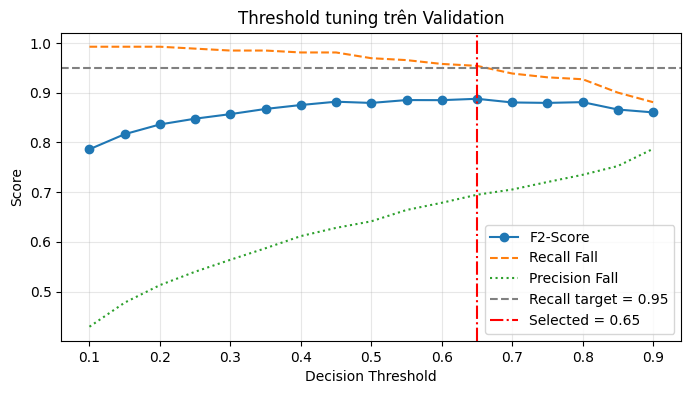

In [27]:
import hashlib

model = tf.keras.models.load_model(best_model_path)
val_probs = model.predict(X_val, verbose=0).ravel()

RECALL_TARGET = 0.95
thresholds = np.round(np.arange(0.1, 0.95, 0.05), 2)
f2_scores = []
recalls = []
precisions = []

for threshold in thresholds:
    predictions = (val_probs >= threshold).astype(int)
    f2_scores.append(fbeta_score(y_val, predictions, beta=2, zero_division=0))
    recalls.append(recall_score(y_val, predictions, zero_division=0))
    precisions.append(precision_score(y_val, predictions, zero_division=0))

f2_scores = np.asarray(f2_scores)
recalls = np.asarray(recalls)
precisions = np.asarray(precisions)

eligible_indices = np.flatnonzero(recalls >= RECALL_TARGET)
if len(eligible_indices) > 0:
    best_idx = eligible_indices[np.argmax(f2_scores[eligible_indices])]
    selection_rule = f"Recall >= {RECALL_TARGET:.2f}, sau đó tối đa hóa F2"
else:
    best_idx = np.lexsort((-f2_scores, -recalls))[0]
    selection_rule = "Không có threshold đạt mục tiêu; ưu tiên Recall cao nhất, sau đó F2"

best_threshold = float(thresholds[best_idx])
DECISION_THRESHOLD = best_threshold
val_preds = (val_probs >= DECISION_THRESHOLD).astype(int)
val_metrics = {
    "Accuracy": accuracy_score(y_val, val_preds),
    "Precision Fall": precision_score(y_val, val_preds, zero_division=0),
    "Recall Fall": recall_score(y_val, val_preds, zero_division=0),
    "F1 Fall": f1_score(y_val, val_preds, zero_division=0),
    "F2 Fall": fbeta_score(y_val, val_preds, beta=2, zero_division=0),
    "F1 Macro": f1_score(y_val, val_preds, average="macro", zero_division=0),
    "ROC-AUC": roc_auc_score(y_val, val_probs),
}

threshold_results = pd.DataFrame({
    "Threshold": thresholds,
    "Precision_Fall": precisions,
    "Recall_Fall": recalls,
    "F2_Fall": f2_scores,
})
threshold_results["Selected"] = False
threshold_results.loc[best_idx, "Selected"] = True
threshold_results.to_csv(MODEL_DIR / "validation_threshold_metrics.csv", index=False)

threshold_selection = {
    "source": "Validation only",
    "selection_rule": selection_rule,
    "recall_target": RECALL_TARGET,
    "decision_threshold": DECISION_THRESHOLD,
    "checkpoint": best_model_path,
    "checkpoint_sha256": hashlib.sha256(Path(best_model_path).read_bytes()).hexdigest(),
}

print(f"Ngưỡng được chọn trên Validation: {DECISION_THRESHOLD:.2f}")
print(f"Quy tắc chọn: {selection_rule}")
for name, value in val_metrics.items():
    print(f"{name}: {value:.6f}")
print(confusion_matrix(y_val, val_preds, labels=[0, 1]))
print(classification_report(y_val, val_preds, labels=[0, 1],
                            target_names=["Normal", "Fall"], digits=4, zero_division=0))

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f2_scores, label="F2-Score", marker="o")
plt.plot(thresholds, recalls, label="Recall Fall", linestyle="--")
plt.plot(thresholds, precisions, label="Precision Fall", linestyle=":")
plt.axhline(RECALL_TARGET, color="gray", linestyle="--", label=f"Recall target = {RECALL_TARGET:.2f}")
plt.axvline(DECISION_THRESHOLD, color="red", linestyle="-.", label=f"Selected = {DECISION_THRESHOLD:.2f}")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold tuning trên Validation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Sample_Test

Đánh giá best_model.keras bằng threshold đã chọn trên Validation. Sample_Test không tham gia chọn threshold.


Đang đọc 586 file CSV từ: /Users/bach/Downloads/AI Projects/Fall_Detection_SIC_Capstone/fall_detection_dataset/Sample_Test
FEATURES:
['AccX', 'AccY', 'AccZ', 'GyrX', 'GyrY', 'GyrZ']
N_FEATURES: 6
WINDOW_SIZE: 200
WINDOW_STEP: 50
DECISION_THRESHOLD: 0.65
FALL_RATIO_THRESHOLD: 0.2
X_test shape: (3714, 1200)
Input dimension: 1200
Total test windows: 3714
Normal: 3392
Fall: 322
Checkpoint: saved_models_6ft/best_model.keras
Accuracy: 0.951804
Precision_Fall: 0.665127
Recall_Fall: 0.894410
F1_Fall: 0.762914
F2_Fall: 0.836723
F1_Macro: 0.868045
ROC_AUC: 0.983708
TN: 3247
FP: 145
FN: 34
TP: 288
FPR: 0.042748
FNR: 0.105590
              precision    recall  f1-score   support

      Normal     0.9896    0.9573    0.9732      3392
        Fall     0.6651    0.8944    0.7629       322

    accuracy                         0.9518      3714
   macro avg     0.8274    0.9258    0.8680      3714
weighted avg     0.9615    0.9518    0.9549      3714

Subject  Windows  Normal  Fall  Accuracy  Precision

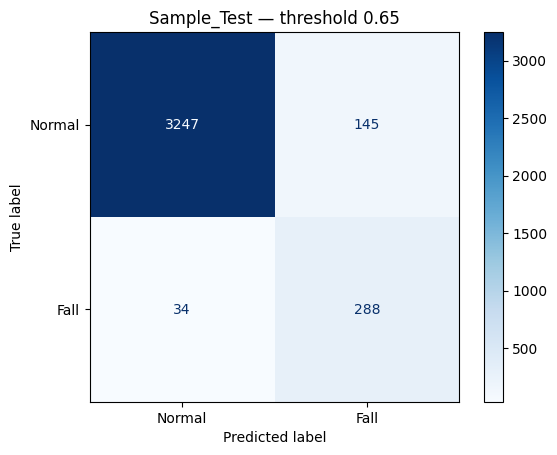

In [28]:
if "best_threshold" not in globals() or "threshold_selection" not in globals():
    raise RuntimeError("Hãy chạy cell tối ưu threshold trên Validation trước khi đánh giá Test.")
if not np.isclose(DECISION_THRESHOLD, best_threshold):
    raise ValueError("DECISION_THRESHOLD không khớp threshold đã chọn trên Validation.")
if hashlib.sha256(Path(best_model_path).read_bytes()).hexdigest() != threshold_selection["checkpoint_sha256"]:
    raise ValueError("Checkpoint đã thay đổi sau khi chọn threshold. Hãy chạy lại cell Validation.")

test_root = resolve_dataset_path(
    "Fall_Detection_SIC_Capstone/fall_detection_dataset/Sample_Test",
    "fall_detection_dataset/Sample_Test",
)
test_subject_dirs = sorted(p for p in test_root.iterdir() if p.is_dir() and p.name.startswith("SA"))
assert [p.name for p in test_subject_dirs] == EXPECTED_TEST_SUBJECTS
df_test_all = load_imu_dataset(test_root)
assert sorted(df_test_all["subject_id"].unique()) == EXPECTED_TEST_SUBJECTS
assert set(df_test_all["subject_id"]).isdisjoint(set(train_df["subject_id"]))
assert set(df_test_all["subject_id"]).isdisjoint(set(val_df["subject_id"]))

X_test_raw, y_test, test_recordings, test_window_subjects = create_sliding_windows(
    df_test_all, feature_cols, target_col, WINDOW_SIZE, WINDOW_STEP
)
X_test = scale_windows(X_test_raw, scaler)
print("FEATURES:")
print(feature_cols)
print("N_FEATURES:", N_FEATURES)
print("WINDOW_SIZE:", WINDOW_SIZE)
print("WINDOW_STEP:", WINDOW_STEP)
print("DECISION_THRESHOLD:", DECISION_THRESHOLD)
print("FALL_RATIO_THRESHOLD:", FALL_RATIO_THRESHOLD)
print("X_test shape:", X_test.shape)
print("Input dimension:", WINDOW_SIZE * N_FEATURES)
print("Total test windows:", len(y_test))
print("Normal:", np.sum(y_test == 0))
print("Fall:", np.sum(y_test == 1))
assert feature_cols == ["AccX", "AccY", "AccZ", "GyrX", "GyrY", "GyrZ"]
assert (N_FEATURES, WINDOW_SIZE, FALL_RATIO_THRESHOLD) == (6, 200, 0.20)
assert 0.0 < DECISION_THRESHOLD < 1.0
assert WINDOW_STEP in EXPECTED_TEST_COUNTS_BY_STEP
assert X_test.shape == (len(y_test), WINDOW_SIZE * N_FEATURES)
recording_sizes = df_test_all.groupby("recording_id", sort=False).size().to_numpy()
expected_total = int(np.maximum((recording_sizes - WINDOW_SIZE) // WINDOW_STEP + 1, 0).sum())
assert len(y_test) == expected_total, "Sai lưới window hoặc có cửa sổ cuối ngoài lưới"
test_counts = (len(y_test), int(np.sum(y_test == 0)), int(np.sum(y_test == 1)))
assert test_counts == EXPECTED_TEST_COUNTS_BY_STEP[WINDOW_STEP], "Test khác protocol đã kiểm tra: dừng để kiểm tra dataset/preprocessing"

model = tf.keras.models.load_model(best_model_path)
assert model.input_shape[1:] == (WINDOW_SIZE * N_FEATURES,)
y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= DECISION_THRESHOLD).astype(int)

def prediction_metrics(labels, probabilities):
    predictions = (probabilities >= DECISION_THRESHOLD).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    return {
        "Accuracy": accuracy_score(labels, predictions),
        "Precision_Fall": precision_score(labels, predictions, zero_division=0),
        "Recall_Fall": recall_score(labels, predictions, zero_division=0),
        "F1_Fall": f1_score(labels, predictions, zero_division=0),
        "F2_Fall": fbeta_score(labels, predictions, beta=2, zero_division=0),
        "F1_Macro": f1_score(labels, predictions, average="macro", zero_division=0),
        "ROC_AUC": roc_auc_score(labels, probabilities) if len(np.unique(labels)) == 2 else np.nan,
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "FPR": fp / (fp + tn) if fp + tn else 0.,
        "FNR": fn / (fn + tp) if fn + tp else 0.,
    }

metrics_test = prediction_metrics(y_test, y_prob)
print("Checkpoint:", best_model_path)
for name, value in metrics_test.items():
    print(f"{name}: {value:.6f}" if isinstance(value, float) else f"{name}: {value}")
print(classification_report(y_test, y_pred, labels=[0, 1],
                            target_names=["Normal", "Fall"], digits=4, zero_division=0))
subject_results = []
for subject in EXPECTED_TEST_SUBJECTS:
    mask = test_window_subjects == subject
    subject_results.append({
        "Subject": subject, "Windows": int(mask.sum()),
        "Normal": int(np.sum(y_test[mask] == 0)), "Fall": int(np.sum(y_test[mask] == 1)),
        **prediction_metrics(y_test[mask], y_prob[mask]),
    })
results_df = pd.DataFrame(subject_results)
print(results_df.round(4).to_string(index=False))
results_df.to_csv(MODEL_DIR / "test_subject_metrics.csv", index=False)
test_result = {
    "WINDOW_SIZE": WINDOW_SIZE, "WINDOW_STEP": WINDOW_STEP,
    "FALL_RATIO_THRESHOLD": FALL_RATIO_THRESHOLD, "DECISION_THRESHOLD": DECISION_THRESHOLD,
    "Total": len(y_test), "Normal": int(np.sum(y_test == 0)), "Fall": int(np.sum(y_test == 1)),
    **metrics_test,
}
pd.DataFrame([test_result]).to_csv(MODEL_DIR / "test_metrics.csv", index=False)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=[0, 1],
                                         display_labels=["Normal", "Fall"], cmap="Blues")
plt.title(f"Sample_Test — threshold {DECISION_THRESHOLD}")
plt.show()


In [29]:
# FULL INTEGER QUANTIZATION: KERAS -> TFLITE INT8 (input/output cũng INT8)
# Calibration dùng X_train đã chuẩn hóa, không dùng validation/test.
# https://www.tensorflow.org/lite/performance/post_training_quantization
from pathlib import Path
from collections import Counter
import hashlib
import json
import numpy as np
import tensorflow as tf
from tensorflow.lite.python import schema_py_generated as tflite_schema

try:
    from ai_edge_litert.interpreter import Interpreter
except ImportError:
    from tensorflow.lite import Interpreter

MODEL_DIR = Path("saved_models_6ft")
KERAS_PATH = MODEL_DIR / "best_model.keras"
TFLITE_PATH = MODEL_DIR / "fall_detection_int8.tflite"
CALIBRATION_SAMPLES = 500


def inspect_int8_model(model_bytes):
    """Reject float/hybrid models before writing TFLite or C/C++ artifacts."""
    flat_model = tflite_schema.Model.GetRootAsModel(model_bytes, 0)
    type_names = {
        value: name for name, value in vars(tflite_schema.TensorType).items()
        if isinstance(value, int)
    }
    tensor_types = Counter()
    for sg_index in range(flat_model.SubgraphsLength()):
        subgraph = flat_model.Subgraphs(sg_index)
        for index in range(subgraph.TensorsLength()):
            tensor_types[type_names[subgraph.Tensors(index).Type()]] += 1
    # INT32 bias/shape tensors are normal in a full INT8 model.
    if not tensor_types["INT8"] or set(tensor_types) - {"INT8", "INT32", "INT64", "BOOL"}:
        raise ValueError(f"Model chưa full INT8: {dict(tensor_types)}")

    interpreter = Interpreter(model_content=model_bytes)
    interpreter.allocate_tensors()
    inputs = interpreter.get_input_details()
    outputs = interpreter.get_output_details()
    if len(inputs) != 1 or len(outputs) != 1:
        raise ValueError("Model phải có đúng một input và một output.")

    def describe(detail, expected_shape):
        scale, zero_point = detail["quantization"]
        if (detail["dtype"] != np.int8
                or detail["shape"].tolist() != expected_shape
                or not np.isfinite(scale) or scale <= 0
                or not -128 <= zero_point <= 127):
            raise ValueError(f"Tensor INT8 không hợp lệ: {detail}")
        return {
            "dtype": "int8", "shape": expected_shape,
            "scale": float(scale), "zero_point": int(zero_point),
        }

    details = {
        "mode": "full_integer_int8",
        "input": describe(inputs[0], [1, WINDOW_SIZE * len(feature_cols)]),
        "output": describe(outputs[0], [1, 1]),
        "tensor_types": dict(tensor_types),
        "tflite_sha256": hashlib.sha256(model_bytes).hexdigest(),
        "size_bytes": len(model_bytes),
    }
    return interpreter, details


for name in ("X_train", "y_train", "X_val", "y_val", "X_test", "y_test", "scaler",
             "DECISION_THRESHOLD", "threshold_selection"):
    if name not in globals():
        raise RuntimeError(f"Thiếu {name}: chạy tuần tự đến hết cell Sample_Test trước khi export.")
if not np.isclose(DECISION_THRESHOLD, threshold_selection["decision_threshold"]):
    raise ValueError("Threshold export không khớp kết quả Validation.")
current_keras_sha256 = hashlib.sha256(KERAS_PATH.read_bytes()).hexdigest()
if current_keras_sha256 != threshold_selection["checkpoint_sha256"]:
    raise ValueError("Checkpoint đã thay đổi sau khi chọn threshold. Hãy chạy lại Validation và Test.")
expected_input_size = WINDOW_SIZE * len(feature_cols)
calibration_source = np.asarray(X_train, dtype=np.float32)
calibration_labels = np.asarray(y_train).reshape(-1)
if (calibration_source.ndim != 2
        or calibration_source.shape != (len(calibration_labels), expected_input_size)
        or not np.all(np.isfinite(calibration_source))):
    raise ValueError("X_train phải là cửa sổ đã chuẩn hóa, shape (N, 1200), không chứa NaN/Inf.")

# Lấy mẫu có cả Fall/Normal để calibration không bỏ sót lớp ngã hiếm.
rng = np.random.default_rng(42)
class_indices = [np.flatnonzero(calibration_labels == label) for label in (0, 1)]
if any(len(indices) == 0 for indices in class_indices):
    raise ValueError("Calibration cần có cả mẫu Normal và Fall trong train.")
calibration_indices = np.concatenate([
    rng.choice(indices, size=min(len(indices), CALIBRATION_SAMPLES // 2), replace=False)
    for indices in class_indices
])
rng.shuffle(calibration_indices)


def representative_dataset():
    # Converter nhận FLOAT32 để đo range; file xuất và inference dùng INT8.
    for index in calibration_indices:
        yield [calibration_source[index:index + 1]]


model_export = tf.keras.models.load_model(KERAS_PATH, compile=False)
if model_export.input_shape[1:] != (expected_input_size,):
    raise ValueError(f"Keras model không khớp 6 features: {model_export.input_shape}")

converter = tf.lite.TFLiteConverter.from_keras_model(model_export)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_model = converter.convert()
int8_interpreter, quantization_metadata = inspect_int8_model(tflite_model)
quantization_metadata["calibration"] = {
    "source": "X_train (scaled, original training windows only)",
    "seed": 42,
    "samples": int(len(calibration_indices)),
    "normal": int(np.sum(calibration_labels[calibration_indices] == 0)),
    "fall": int(np.sum(calibration_labels[calibration_indices] == 1)),
}
quantization_metadata["keras_sha256"] = current_keras_sha256

# Đánh giá sau quantization trên validation riêng; không dùng validation để calibration.
input_detail = int8_interpreter.get_input_details()[0]
output_detail = int8_interpreter.get_output_details()[0]
input_scale, input_zero_point = input_detail["quantization"]
output_scale, output_zero_point = output_detail["quantization"]
validation_data = np.asarray(X_val, dtype=np.float32)
if (validation_data.ndim != 2 or validation_data.shape != (len(y_val), expected_input_size)
        or not len(validation_data) or not np.all(np.isfinite(validation_data))):
    raise ValueError("X_val/y_val không hợp lệ.")
def predict_int8(interpreter, data):
    probabilities = []
    for window in np.asarray(data, dtype=np.float32):
        quantized_input = np.clip(
            np.rint(window / input_scale) + input_zero_point, -128, 127
        ).astype(np.int8).reshape(1, -1)
        interpreter.set_tensor(input_detail["index"], quantized_input)
        interpreter.invoke()
        quantized_output = interpreter.get_tensor(output_detail["index"])
        probabilities.append((int(quantized_output[0, 0]) - output_zero_point) * output_scale)
    return np.asarray(probabilities)


int8_val_probs = predict_int8(int8_interpreter, validation_data)
float_val_probs = model_export.predict(validation_data, verbose=0).ravel()

int8_thresholds = np.round(np.arange(0.1, 0.95, 0.05), 2)
int8_f2_scores = []
int8_recalls = []
int8_precisions = []
for threshold in int8_thresholds:
    predictions = (int8_val_probs >= threshold).astype(np.int32)
    int8_f2_scores.append(fbeta_score(y_val, predictions, beta=2, zero_division=0))
    int8_recalls.append(recall_score(y_val, predictions, zero_division=0))
    int8_precisions.append(precision_score(y_val, predictions, zero_division=0))
int8_f2_scores = np.asarray(int8_f2_scores)
int8_recalls = np.asarray(int8_recalls)
int8_precisions = np.asarray(int8_precisions)
int8_eligible = np.flatnonzero(int8_recalls >= RECALL_TARGET)
if len(int8_eligible) > 0:
    int8_best_idx = int8_eligible[np.argmax(int8_f2_scores[int8_eligible])]
    int8_selection_rule = f"Recall >= {RECALL_TARGET:.2f}, sau đó tối đa hóa F2"
else:
    int8_best_idx = np.lexsort((-int8_f2_scores, -int8_recalls))[0]
    int8_selection_rule = "Không có threshold đạt mục tiêu; ưu tiên Recall cao nhất, sau đó F2"
DEPLOYMENT_THRESHOLD = float(int8_thresholds[int8_best_idx])

int8_threshold_results = pd.DataFrame({
    "Threshold": int8_thresholds,
    "Precision_Fall": int8_precisions,
    "Recall_Fall": int8_recalls,
    "F2_Fall": int8_f2_scores,
})
int8_threshold_results["Selected"] = False
int8_threshold_results.loc[int8_best_idx, "Selected"] = True
int8_threshold_results.to_csv(MODEL_DIR / "int8_validation_threshold_metrics.csv", index=False)


def evaluation_metrics(labels, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(np.int32)
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    return {
        "accuracy": float(accuracy_score(labels, predictions)),
        "precision": float(precision_score(labels, predictions, zero_division=0)),
        "recall": float(recall_score(labels, predictions, zero_division=0)),
        "f1": float(f1_score(labels, predictions, zero_division=0)),
        "f2": float(fbeta_score(labels, predictions, beta=2, zero_division=0)),
        "f1_macro": float(f1_score(labels, predictions, average="macro", zero_division=0)),
        "roc_auc": float(roc_auc_score(labels, probabilities)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


quantization_metadata["validation"] = {
    "samples": len(validation_data),
    "decision_operator": ">=",
    "float32_threshold": float(DECISION_THRESHOLD),
    "int8_threshold": DEPLOYMENT_THRESHOLD,
    "int8_selection_rule": int8_selection_rule,
    "float32": evaluation_metrics(y_val, float_val_probs, DECISION_THRESHOLD),
    "int8": evaluation_metrics(y_val, int8_val_probs, DEPLOYMENT_THRESHOLD),
    "int8_at_float32_threshold": evaluation_metrics(y_val, int8_val_probs, DECISION_THRESHOLD),
    "mean_absolute_probability_error": float(np.mean(np.abs(float_val_probs - int8_val_probs))),
}

test_data = np.asarray(X_test, dtype=np.float32)
if (test_data.ndim != 2 or test_data.shape != (len(y_test), expected_input_size)
        or not len(test_data) or not np.all(np.isfinite(test_data))):
    raise ValueError("X_test/y_test không hợp lệ.")
int8_test_probs = predict_int8(int8_interpreter, test_data)
float_test_probs = model_export.predict(test_data, verbose=0).ravel()
quantization_metadata["test"] = {
    "samples": len(test_data),
    "threshold_tuned_on": "Validation only",
    "float32_threshold": float(DECISION_THRESHOLD),
    "int8_threshold": DEPLOYMENT_THRESHOLD,
    "float32": evaluation_metrics(y_test, float_test_probs, DECISION_THRESHOLD),
    "int8": evaluation_metrics(y_test, int8_test_probs, DEPLOYMENT_THRESHOLD),
    "mean_absolute_probability_error": float(np.mean(np.abs(float_test_probs - int8_test_probs))),
}
pd.DataFrame([
    {"Model": "Float32", "Threshold": DECISION_THRESHOLD,
     **quantization_metadata["test"]["float32"]},
    {"Model": "INT8", "Threshold": DEPLOYMENT_THRESHOLD,
     **quantization_metadata["test"]["int8"]},
]).to_csv(MODEL_DIR / "int8_test_metrics.csv", index=False)

# Chỉ ghi sau khi đã kiểm tra full INT8 và chạy inference thành công.
MODEL_DIR.mkdir(parents=True, exist_ok=True)
TFLITE_PATH.write_bytes(tflite_model)
(MODEL_DIR / "quantization_report.json").write_text(
    json.dumps(quantization_metadata, ensure_ascii=False, indent=2) + "\n", encoding="utf-8"
)
print(f"Float32 threshold: {DECISION_THRESHOLD:.2f}")
print(f"INT8 deployment threshold: {DEPLOYMENT_THRESHOLD:.2f}")
print(f"TFLite full INT8: {TFLITE_PATH.resolve()}")
print(f"Size: {len(tflite_model):,} bytes ({len(tflite_model) / 1024:.2f} KiB)")
print(json.dumps(quantization_metadata, ensure_ascii=False, indent=2))


INFO:tensorflow:Assets written to: /var/folders/cf/6f5g7m5d5dgg3blzc0clqglh0000gn/T/tmpjd_k5zby/assets


INFO:tensorflow:Assets written to: /var/folders/cf/6f5g7m5d5dgg3blzc0clqglh0000gn/T/tmpjd_k5zby/assets


Saved artifact at '/var/folders/cf/6f5g7m5d5dgg3blzc0clqglh0000gn/T/tmpjd_k5zby'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1200), dtype=tf.float32, name='input_sensor_features')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  13497680720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13497685712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13497685328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13497684560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13497686480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13497683024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13497686096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13497681872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13497680144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13497688784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13497687

/Users/bach/Downloads/AI Projects/.venv/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1789545095.321448 7550435 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1789545095.321644 7550435 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1789545095.326846 7550435 reader.cc:83] Reading SavedModel from: /var/folders/cf/6f5g7m5d5dgg3blzc0clqglh0000gn/T/tmpjd_k5zby
I0000 00:00:1789545095.329465 7550435 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1789545095.329475 7550435 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/cf/6f5g7m5d5dgg3blzc0clqglh0000gn/T/tmpjd_k5zby
I0000 00:00:1789545095.354581 7550435 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1789545095.359617 7550435 loader.cc:236] Restoring SavedM

Float32 threshold: 0.65
INT8 deployment threshold: 0.50
TFLite full INT8: /Users/bach/Downloads/AI Projects/Fall_Detection_SIC_Capstone/saved_models_6ft/fall_detection_int8.tflite
Size: 121,200 bytes (118.36 KiB)
{
  "mode": "full_integer_int8",
  "input": {
    "dtype": "int8",
    "shape": [
      1,
      1200
    ],
    "scale": 0.1298178732395172,
    "zero_point": -5
  },
  "output": {
    "dtype": "int8",
    "shape": [
      1,
      1
    ],
    "scale": 0.00390625,
    "zero_point": -128
  },
  "tensor_types": {
    "INT8": 128,
    "INT32": 55
  },
  "tflite_sha256": "9075e12b158e21fb2ff8c51238babcfd9b43fd591513db0f613fee7544e253dd",
  "size_bytes": 121200,
  "calibration": {
    "source": "X_train (scaled, original training windows only)",
    "seed": 42,
    "samples": 500,
    "normal": 250,
    "fall": 250
  },
  "keras_sha256": "fb3c1eac268cc97d4c32841311136984896770df4bc3585ee102dc7a5a758a08",
  "validation": {
    "samples": 3283,
    "decision_operator": ">=",
    "f

In [30]:
# LƯU FILE PKL: SCALER VÀ METADATA (ACC/GYR XYZ)
# Chạy sau cell export TFLite INT8, trước cell export C/C++.
from pathlib import Path
import joblib

pkl_dir = Path("saved_models_6ft")

if "scaler" not in globals() or not hasattr(scaler, "mean_"):
    raise RuntimeError("Hãy chạy cell chuẩn hóa để có scaler đã fit trước khi lưu.")
if "feature_cols" not in globals() or list(feature_cols) != ["AccX", "AccY", "AccZ", "GyrX", "GyrY", "GyrZ"]:
    raise ValueError("Cell này lưu cấu hình 6 đặc trưng ACC/GYR.")
if len(scaler.mean_) != len(feature_cols):
    raise ValueError("Scaler không khớp 6 đặc trưng ACC/GYR.")
if ("threshold_selection" not in globals()
        or not np.isclose(DECISION_THRESHOLD, threshold_selection["decision_threshold"])):
    raise RuntimeError("Hãy chạy cell tối ưu threshold trên Validation trước khi lưu.")
if "DEPLOYMENT_THRESHOLD" not in globals():
    raise RuntimeError("Hãy chạy cell export/đánh giá INT8 trước khi lưu.")

if "quantization_metadata" not in globals():
    raise RuntimeError("Hãy chạy cell export TFLite INT8 trước khi lưu metadata.")
if hashlib.sha256((pkl_dir / "fall_detection_int8.tflite").read_bytes()).hexdigest() != quantization_metadata["tflite_sha256"]:
    raise ValueError("TFLite đã thay đổi. Hãy chạy lại cell export INT8.")

metadata = {
    "feature_cols": list(feature_cols),
    "window_size": int(WINDOW_SIZE),
    "window_step": int(WINDOW_STEP),
    "fall_ratio_threshold": float(FALL_RATIO_THRESHOLD),
    "include_final_window": False,
    "decision_threshold": float(DEPLOYMENT_THRESHOLD),
    "keras_decision_threshold": float(DECISION_THRESHOLD),
    "threshold_source": "INT8 Validation only",
    "threshold_selection_rule": quantization_metadata["validation"]["int8_selection_rule"],
    "scaler_mode": "per_feature",
    "decision_operator": ">=",
    "input_size": int(WINDOW_SIZE * len(feature_cols)),
    "quantization": quantization_metadata,
}

pkl_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(scaler, pkl_dir / "scaler.pkl")
joblib.dump(metadata, pkl_dir / "metadata.pkl")

print("Đã lưu:", (pkl_dir / "scaler.pkl").resolve())
print("Đã lưu:", (pkl_dir / "metadata.pkl").resolve())


Đã lưu: /Users/bach/Downloads/AI Projects/Fall_Detection_SIC_Capstone/saved_models_6ft/scaler.pkl
Đã lưu: /Users/bach/Downloads/AI Projects/Fall_Detection_SIC_Capstone/saved_models_6ft/metadata.pkl


In [31]:
# EXPORT TFLITE INT8 + SCALER -> model_data.cc / model_data.h / scaler_data.h
# Chạy lần lượt: export INT8 -> lưu scaler/metadata -> cell này.
from pathlib import Path
import hashlib
import shutil
import joblib
import numpy as np

MODEL_DIR = Path("saved_models_6ft")
TFLITE_PATH = MODEL_DIR / "fall_detection_int8.tflite"
MODEL_CC_PATH = MODEL_DIR / "model_data.cc"
MODEL_H_PATH = MODEL_DIR / "model_data.h"
SCALER_H_PATH = MODEL_DIR / "scaler_data.h"

model_bytes = TFLITE_PATH.read_bytes()
_, checked_quantization = inspect_int8_model(model_bytes)
metadata_export = joblib.load(MODEL_DIR / "metadata.pkl")
scaler_export = joblib.load(MODEL_DIR / "scaler.pkl")
if metadata_export.get("quantization", {}).get("tflite_sha256") != checked_quantization["tflite_sha256"]:
    raise ValueError("Metadata không khớp TFLite hiện tại. Chạy lại cell lưu metadata.")
if metadata_export.get("quantization", {}).get("keras_sha256") != hashlib.sha256((MODEL_DIR / "best_model.keras").read_bytes()).hexdigest():
    raise ValueError("Checkpoint Keras đã thay đổi sau khi export TFLite.")

EXPORT_FEATURES = list(metadata_export["feature_cols"])
EXPORT_WINDOW_SIZE = int(metadata_export["window_size"])
EXPORT_WINDOW_STEP = int(metadata_export["window_step"])
EXPORT_THRESHOLD = float(metadata_export["decision_threshold"])
NUM_FEATURES = len(EXPORT_FEATURES)
EXPECTED_INPUT_SIZE = EXPORT_WINDOW_SIZE * NUM_FEATURES
scaler_mean = np.asarray(scaler_export.mean_, dtype=np.float32).reshape(-1)
scaler_scale = np.asarray(scaler_export.scale_, dtype=np.float32).reshape(-1)
if (EXPORT_FEATURES != ["AccX", "AccY", "AccZ", "GyrX", "GyrY", "GyrZ"]
        or metadata_export.get("scaler_mode") != "per_feature"
        or len(scaler_mean) != NUM_FEATURES or len(scaler_scale) != NUM_FEATURES
        or not np.all(np.isfinite(scaler_mean)) or not np.all(np.isfinite(scaler_scale))
        or np.any(scaler_scale <= 0)
        or checked_quantization["input"]["shape"] != [1, EXPECTED_INPUT_SIZE]):
    raise ValueError("Model/scaler/metadata không khớp cấu hình 6 features.")

input_quant = checked_quantization["input"]
output_quant = checked_quantization["output"]

model_h = """#ifndef MODEL_DATA_H_
#define MODEL_DATA_H_

#include <cstddef>
#include <cstdint>

// Full integer INT8 TFLite model, including INT8 input and output.
extern const unsigned char g_fall_model[];
extern const unsigned int g_fall_model_len;

#endif  // MODEL_DATA_H_
"""
model_array_text = ",\n".join(
    "    " + ", ".join(f"0x{byte:02x}" for byte in model_bytes[start:start + 12])
    for start in range(0, len(model_bytes), 12)
)
model_cc = f"""#include "model_data.h"

// Full integer INT8. TFLite SHA256: {checked_quantization['tflite_sha256']}
alignas(16) const unsigned char g_fall_model[] = {{
{model_array_text}
}};

const unsigned int g_fall_model_len = sizeof(g_fall_model);
"""


def format_float_array(values):
    return ", ".join(f"{float(value):.9e}f" for value in values)


scaler_h = f"""#ifndef SCALER_DATA_H_
#define SCALER_DATA_H_

#include <cmath>
#include <cstdint>

constexpr int kWindowSize = {EXPORT_WINDOW_SIZE};
constexpr int kWindowStep = {EXPORT_WINDOW_STEP};
constexpr int kNumFeatures = {NUM_FEATURES};
constexpr int kInputSize = {EXPECTED_INPUT_SIZE};
constexpr int kScalerSize = {NUM_FEATURES};
// Dequantized probability >= kFallThreshold -> Fall.
// Keep the Python threshold as double to preserve its comparison semantics.
constexpr double kFallThreshold = {EXPORT_THRESHOLD:.17g};

// Flattened window: [AccX, AccY, AccZ, GyrX, GyrY, GyrZ] for each time step, oldest first.
constexpr float kScalerMean[kScalerSize] = {{{format_float_array(scaler_mean)}}};
constexpr float kScalerScale[kScalerSize] = {{{format_float_array(scaler_scale)}}};

constexpr float kInputScale = {input_quant['scale']:.9e}f;
constexpr int kInputZeroPoint = {input_quant['zero_point']};
constexpr float kOutputScale = {output_quant['scale']:.9e}f;
constexpr int kOutputZeroPoint = {output_quant['zero_point']};

inline float StandardizeInput(float value, int index) {{
    const int feature_index = index % kNumFeatures;
    return (value - kScalerMean[feature_index]) / kScalerScale[feature_index];
}}

inline int8_t QuantizeScaledInput(float scaled_value) {{
    // nearbyint uses round-to-nearest-even by default, matching numpy.rint.
    const float quantized = std::nearbyint(scaled_value / kInputScale) + kInputZeroPoint;
    const float clipped = quantized < -128.0f ? -128.0f : (quantized > 127.0f ? 127.0f : quantized);
    return static_cast<int8_t>(clipped);
}}

inline int8_t QuantizeInput(float raw_value, int flattened_index) {{
    return QuantizeScaledInput(StandardizeInput(raw_value, flattened_index));
}}

inline float DequantizeOutput(int8_t quantized_value) {{
    return (static_cast<int>(quantized_value) - kOutputZeroPoint) * kOutputScale;
}}

// Firmware: input->data.int8[i] = QuantizeInput(raw_window[i], i);
// float probability = DequantizeOutput(output->data.int8[0]);
// bool fall = probability >= kFallThreshold;
#endif  // SCALER_DATA_H_
"""

MODEL_H_PATH.write_text(model_h, encoding="utf-8")
MODEL_CC_PATH.write_text(model_cc, encoding="utf-8")
SCALER_H_PATH.write_text(scaler_h, encoding="utf-8")

# Byte-for-byte verification: the C array must embed exactly this INT8 file.
import re
embedded_bytes = bytes(int(value, 16) for value in re.findall(r"0x([0-9a-fA-F]{2})", MODEL_CC_PATH.read_text()))
assert embedded_bytes == model_bytes, "C array không khớp TFLite!"

firmware_candidates = [
    Path("esp32s3-tinyml-fall-detector/main/model"),
    Path("Fall_Detection_SIC_Capstone/esp32s3-tinyml-fall-detector/main/model"),
]
firmware_dirs = [directory for directory in firmware_candidates if directory.is_dir()]
if len(firmware_dirs) != 1:
    raise FileNotFoundError(f"Không xác định được duy nhất thư mục model firmware: {firmware_dirs}")
firmware_dir = firmware_dirs[0]
for source_path in (MODEL_CC_PATH, MODEL_H_PATH, SCALER_H_PATH):
    destination = firmware_dir / source_path.name
    shutil.copy2(source_path, destination)
    if destination.read_bytes() != source_path.read_bytes():
        raise ValueError(f"Copy firmware không khớp: {destination}")

print(f"INT8 binary / embedded array: {len(model_bytes):,} bytes ({len(model_bytes) / 1024:.2f} KiB)")
print(f"Input: INT8 [1, {EXPECTED_INPUT_SIZE}] | Output: INT8 [1, 1]")
for path in (MODEL_CC_PATH, MODEL_H_PATH, SCALER_H_PATH):
    print(f"Generated: {path} ({path.stat().st_size:,} bytes văn bản)")
print(f"Firmware synchronized: {firmware_dir.resolve()}")


INT8 binary / embedded array: 121,200 bytes (118.36 KiB)
Input: INT8 [1, 1200] | Output: INT8 [1, 1]
Generated: saved_models_6ft/model_data.cc (767,841 bytes văn bản)
Generated: saved_models_6ft/model_data.h (265 bytes văn bản)
Generated: saved_models_6ft/scaler_data.h (2,045 bytes văn bản)
Firmware synchronized: /Users/bach/Downloads/AI Projects/Fall_Detection_SIC_Capstone/esp32s3-tinyml-fall-detector/main/model
